The objective of part 4 is to test the scale invariance of $\Delta B _s$ at different s (scale) values, by plotting the different normalized pdf followed by the sample at varying $s$ values

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sp

filename='Y1.txt'
data = pd.read_csv(filename).to_numpy()
B = np.cumsum(data)
s_values = [8, 16, 32, 64, 128, 256]
deltaB = [] # empty list, to be filled with s values
df = pd.DataFrame()

def poly_fit(x, y, order=3):
    # revert order of coeffs from x^0 to x^3
    coeff = np.polyfit(x, y, order)
    p = np.poly1d(coeff)
    return p(x)

def get_deviation(y, s):
    #preparo array deviations
    deviations = np.zeros(len(y))

    x = np.arange(len(y))
    segment_length = 2*s
    # numero di segmenti su cui fare sliding
    
    for k in range(0, len(y), segment_length):
        # prendo un segmento e faccio fit
        x_slice = x[k:k+segment_length]
        y_slice = y[k:k+segment_length]
        y_fitted = poly_fit(x_slice, y_slice, order=3)
        #plt.plot(x_slice, y_slice)
        #plt.plot(x_slice, y_fitted)
        dev = y_slice-y_fitted
        
        deviations[k:k+segment_length] = dev
    return deviations
for s in s_values:
    z = get_deviation(B, s)
    deltaB.append(z)

    df[s] = z

C:\Users\lcdit\AppData\Local\Temp\ipykernel_12108\2280886731.py:15: RankWarning: Polyfit may be poorly conditioned
  coeff = np.polyfit(x, y, order)
C:\Users\lcdit\AppData\Local\Temp\ipykernel_12108\2280886731.py:15: RankWarning: Polyfit may be poorly conditioned
  coeff = np.polyfit(x, y, order)
C:\Users\lcdit\AppData\Local\Temp\ipykernel_12108\2280886731.py:15: RankWarning: Polyfit may be poorly conditioned
  coeff = np.polyfit(x, y, order)
C:\Users\lcdit\AppData\Local\Temp\ipykernel_12108\2280886731.py:15: RankWarning: Polyfit may be poorly conditioned
  coeff = np.polyfit(x, y, order)
C:\Users\lcdit\AppData\Local\Temp\ipykernel_12108\2280886731.py:15: RankWarning: Polyfit may be poorly conditioned
  coeff = np.polyfit(x, y, order)
C:\Users\lcdit\AppData\Local\Temp\ipykernel_12108\2280886731.py:15: RankWarning: Polyfit may be poorly conditioned
  coeff = np.polyfit(x, y, order)


In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_collapse(increments_df):
    """
    increments_df è un dataframe dove le colonne sono i diversi valori di s
    """
    plt.figure(figsize=(10, 6))
    
    # Calcolo deviazioni standard per tutte le colonne

    sigmas = increments_df.std()

    def plot_single_column(col):
        s = col.name
        sigma = sigmas[s]
        
        # Rimozione eventuali NaN (non dovrebbero essercene)
        data = col.dropna()

        nbins = int(np.sqrt(len(data)))
        pdf, bin_edges = np.histogram(data, bins=nbins, density=True)
        

        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        
        # Plot diretto
        plt.semilogy(bin_centers / sigma, pdf * sigma, ls='', marker = 'o',label=f's={s}',ms = 3)

    # Applichiamo la funzione a ogni colonna (axis=0 è il default)
    increments_df.apply(plot_single_column)

    plt.title('Data Collapse: Rescaled PDFs')
    plt.xlabel(r'$\Delta_s B / \sigma_s$')
    plt.ylabel(r'$\sigma_s \cdot P(\Delta_s B)$')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.show()

## Testing the scale invariance of the process:

To test the scale invariance of  $\Delta B _s$, we started by normalizing the pdfs obtained from the dataset at different $s$ values.


After having obtained $\Delta B _s(i) = B^*(i+s)- B^*(i)$ , we calculated $\sigma_s$ for each dataset, and we computed the pdfs of $\Delta B _s$ from the histogram over their distribution. To normalize these distribution and check the scale invariance, we did the variable change 

$\Delta B _s \rightarrow \Delta B _s/\sigma_s$

and having to maintain the integral to one,

$y = P ( \Delta B _s ) \rightarrow y' = P ( \Delta B _s ) \cdot \sigma_s $

, since

$
\int^{+\infty}_{-\infty}P(\Delta B_s)\ dB_s = 1 = \int^{+\infty}_{-\infty} ( P(\Delta B_s)\cdot \sigma_s )\  dB_s/\sigma_s
$




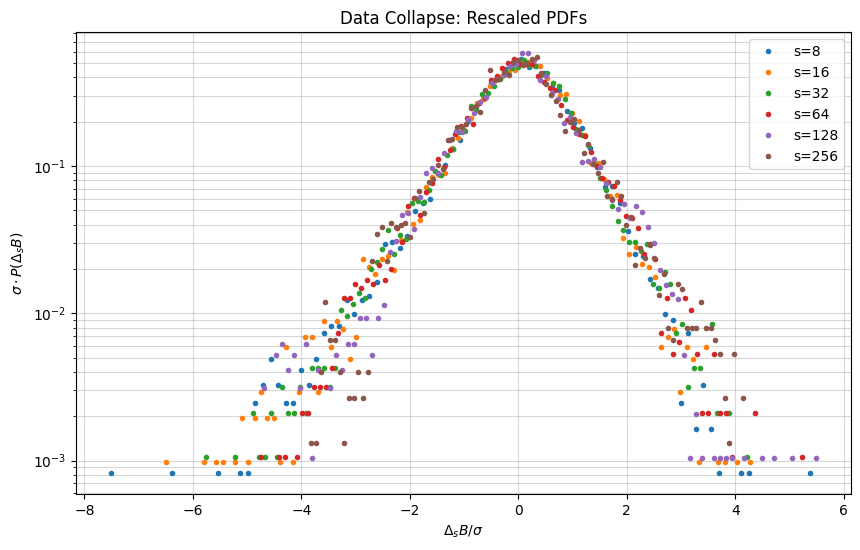

In [84]:
plot_collapse(df)